# TP5 — Real-time Banking Fraud Detection Dashboard

Live monitoring of per-user statistics produced by Spark Structured Streaming.

**Requirements covered:** last 20 active users, last 10 seconds of activity, windowed metrics (3h / 7d / 3w / 3mo), lifetime aggregates, auto-refresh.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output, display
import ipywidgets as widgets

OUTPUT_BASE = Path(os.getenv("OUTPUT_BASE", "/workspace/data/output"))
REFRESH_SECONDS = 5

WINDOW_LABELS = {
    "3h": "Last 3 hours (sliding)",
    "7d": "Last 7 days (sliding)",
    "3w": "Last 3 weeks (sliding)",
    "3mo": "Last 3 months (sliding)",
}

print("Output directory:", OUTPUT_BASE)

Output directory: /workspace/data/output


In [2]:
def read_latest_parquet_snapshot(path: Path) -> pd.DataFrame:
    """Read only the latest Spark snapshot (safe while directories are overwritten)."""
    if not path.exists():
        return pd.DataFrame()
    try:
        files = [f for f in path.glob("**/*.parquet") if f.is_file()]
    except OSError:
        return pd.DataFrame()
    if not files:
        return pd.DataFrame()

    latest_ts = max(f.stat().st_mtime for f in files)
    latest_files = [f for f in files if latest_ts - f.stat().st_mtime < 2]

    frames = []
    for f in latest_files:
        try:
            frames.append(pd.read_parquet(f))
        except Exception:
            continue
    if not frames:
        return pd.DataFrame()

    df = pd.concat(frames, ignore_index=True)
    if "window_end" in df.columns:
        df = df.sort_values("window_end").drop_duplicates(
            subset=["user_id", "direction", "window_end"], keep="last"
        )
    return df


def load_recent_activity() -> pd.DataFrame:
    df = read_latest_parquet_snapshot(OUTPUT_BASE / "recent_activity")
    if df.empty or "event_time" not in df.columns:
        return df
    df = df.copy()
    df["event_time"] = pd.to_datetime(df["event_time"], utc=True)
    cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(seconds=10)
    recent = df[df["event_time"] >= cutoff]
    return recent if not recent.empty else df.head(50)


def load_recent_users() -> pd.DataFrame:
    return read_latest_parquet_snapshot(OUTPUT_BASE / "recent_users")


def load_lifetime() -> pd.DataFrame:
    return read_latest_parquet_snapshot(OUTPUT_BASE / "lifetime")


def load_window(label: str) -> pd.DataFrame:
    return read_latest_parquet_snapshot(OUTPUT_BASE / f"windowed_{label}")

In [3]:
def highlight_anomalies(df: pd.DataFrame, amount_col: str = "amount") -> pd.DataFrame:
    """Flag high amounts without pandas Styler (no jinja2 required)."""
    if df.empty or amount_col not in df.columns:
        return df
    out = df.copy()
    q95 = df[amount_col].quantile(0.95) if len(df) > 5 else df[amount_col].max()
    out["anomaly"] = out[amount_col].apply(
        lambda v: "HIGH" if pd.notna(v) and float(v) >= q95 else ""
    )
    if "tx_type" in out.columns:
        out.loc[out["tx_type"] == "fraud_alert", "anomaly"] = "FRAUD"
    return out


def merge_user_metrics(recent_users: pd.DataFrame, lifetime: pd.DataFrame, window_dfs: dict) -> pd.DataFrame:
    if recent_users.empty:
        return pd.DataFrame()
    users = recent_users["user_id"].tolist()
    rows = []
    for uid in users:
        row = {"user_id": uid}
        if not lifetime.empty:
            for direction in ("sent", "received"):
                sub = lifetime[(lifetime["user_id"] == uid) & (lifetime["direction"] == direction)]
                if not sub.empty:
                    s = sub.iloc[-1]
                    row[f"lifetime_{direction}_count"] = s.get("tx_count")
                    row[f"lifetime_{direction}_avg"] = round(float(s.get("avg_amount", 0)), 2)
                    row[f"lifetime_distinct_{'receivers' if direction == 'sent' else 'senders'}"] = s.get(
                        "distinct_counterparties"
                    )
        for label, wdf in window_dfs.items():
            if wdf.empty:
                continue
            sub = wdf[wdf["user_id"] == uid]
            if sub.empty:
                continue
            latest = sub.sort_values("window_end").iloc[-1]
            for direction in ("sent", "received"):
                dsub = sub[sub["direction"] == direction]
                if dsub.empty:
                    continue
                dlatest = dsub.sort_values("window_end").iloc[-1]
                row[f"{label}_{direction}_avg"] = round(float(dlatest.get("avg_amount", 0)), 2)
                row[f"{label}_{direction}_count"] = dlatest.get("tx_count")
                row[f"{label}_{direction}_distinct"] = dlatest.get("distinct_counterparties")
        rows.append(row)
    return pd.DataFrame(rows)

In [4]:
def render_dashboard():
    clear_output(wait=True)
    try:
        activity = load_recent_activity()
        recent_users = load_recent_users()
        lifetime = load_lifetime()
        window_dfs = {k: load_window(k) for k in WINDOW_LABELS}
    except Exception as exc:
        display(widgets.HTML(f"<p style='color:red'>Read error (retry in a few seconds): {exc}</p>"))
        return

    display(widgets.HTML("<h2>Last 10 seconds — transactions</h2>"))
    if activity.empty:
        display(widgets.HTML("<p><i>Waiting for Spark output in recent_activity ...</i></p>"))
    else:
        display(highlight_anomalies(activity.head(50)))

    display(widgets.HTML("<h2>Last 20 active users</h2>"))
    if recent_users.empty:
        display(widgets.HTML("<p><i>Waiting for recent_users ...</i></p>"))
    else:
        display(recent_users)

    summary = merge_user_metrics(recent_users, lifetime, window_dfs)
    display(widgets.HTML("<h2>Per-user metrics (windowed + lifetime)</h2>"))
    if summary.empty:
        display(widgets.HTML("<p><i>No merged metrics yet.</i></p>"))
    else:
        display(summary)

    if not activity.empty and "amount" in activity.columns:
        fig, ax = plt.subplots(figsize=(10, 4))
        colors = [
            "#c44" if str(t) == "fraud_alert" else "#48a"
            for t in activity.get("tx_type", ["transfer"] * len(activity))
        ]
        activity["amount"].plot(kind="bar", ax=ax, color=colors[: len(activity)])
        ax.set_title("Transaction amounts (last ~10s or latest batch)")
        ax.set_xlabel("row")
        ax.set_ylabel("MRU")
        plt.tight_layout()
        plt.show()

    for label, title in WINDOW_LABELS.items():
        wdf = window_dfs[label]
        if wdf.empty:
            continue
        display(widgets.HTML(f"<h3>{title}</h3>"))
        if recent_users.empty:
            display(wdf.tail(15))
        else:
            uid_list = recent_users["user_id"].tolist()
            display(wdf[wdf["user_id"].isin(uid_list)].tail(20))


print("Dashboard renderer ready.")

Dashboard renderer ready.


HTML(value='<h2>Last 10 seconds — transactions</h2>')

,tx_id,send_id,receive_id,amount,date,tx_type,event_time,anomaly
0,41771ac7-b806-4419-b489-b66640d0754f,user_a_000298,user_b_000213,6.14,2026-05-21T01:46:03Z,transfer,2026-05-21 01:46:03+00:00,
1,64eb7c65-fc2a-4119-86b9-35a16e81fe4b,user_b_000263,user_a_000221,32.10,2026-05-21T01:45:52Z,transfer,2026-05-21 01:45:52+00:00,HIGH
2,31079923-cc70-4d8a-bf79-00063d461031,user_a_000135,user_a_000070,8.14,2026-05-21T01:45:48Z,transfer,2026-05-21 01:45:48+00:00,
3,d4f53c2e-9543-4015-9ab4-a89264a02d97,user_b_000343,user_a_000191,4.01,2026-05-21T01:45:43Z,transfer,2026-05-21 01:45:43+00:00,
4,b280baee-b552-461e-a5aa-c203d1a98f30,user_a_000350,user_a_000367,1.51,2026-05-21T01:45:37Z,transfer,2026-05-21 01:45:37+00:00,


HTML(value='<h2>Last 20 active users</h2>')

,user_id,last_seen
0,user_b_000213,2026-05-21 01:46:03
1,user_a_000298,2026-05-21 01:46:03
2,user_b_000263,2026-05-21 01:45:52
3,user_a_000221,2026-05-21 01:45:52
4,user_a_000070,2026-05-21 01:45:48
5,user_a_000135,2026-05-21 01:45:48
6,user_b_000343,2026-05-21 01:45:43
7,user_a_000191,2026-05-21 01:45:43
8,user_a_000350,2026-05-21 01:45:37
9,user_a_000367,2026-05-21 01:45:37


HTML(value='<h2>Per-user metrics (windowed + lifetime)</h2>')

,user_id,lifetime_received_count,lifetime_received_avg,lifetime_distinct_senders,3h_received_avg,3h_received_count,3h_received_distinct,7d_received_avg,7d_received_count,7d_received_distinct,...,3h_sent_distinct,7d_sent_avg,7d_sent_count,7d_sent_distinct,3w_sent_avg,3w_sent_count,3w_sent_distinct,3mo_sent_avg,3mo_sent_count,3mo_sent_distinct
0,user_b_000213,1.0,6.14,1.0,6.14,1.0,1.0,6.14,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,user_a_000298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,6.14,1.0,1.0,6.14,1.0,1.0,6.14,1.0,1.0
2,user_b_000263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,32.10,1.0,1.0,32.10,1.0,1.0,32.10,1.0,1.0
3,user_a_000221,1.0,32.10,1.0,32.10,1.0,1.0,32.10,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,user_a_000070,1.0,8.14,1.0,8.14,1.0,1.0,8.14,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,user_a_000135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,8.14,1.0,1.0,8.14,1.0,1.0,8.14,1.0,1.0
6,user_b_000343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,4.01,1.0,1.0,4.01,1.0,1.0,4.01,1.0,1.0
7,user_a_000191,1.0,4.01,1.0,4.01,1.0,1.0,4.01,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,user_a_000350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.51,1.0,1.0,1.51,1.0,1.0,1.51,1.0,1.0
9,user_a_000367,2.0,1.56,2.0,1.56,2.0,2.0,1.56,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


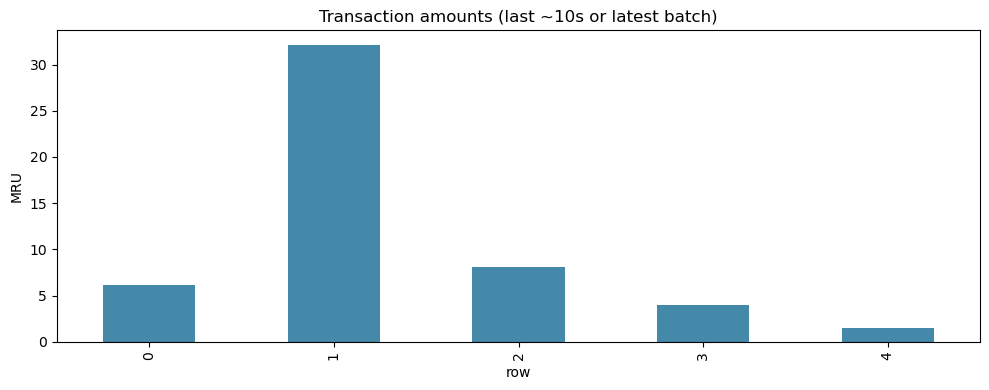

HTML(value='<h3>Last 3 hours (sliding)</h3>')

,user_id,direction,avg_amount,tx_count,total_amount,distinct_counterparties,window_start,window_end,processed_at
987,user_a_000350,sent,1.51,1,1.51,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
989,user_a_000135,sent,8.14,1,8.14,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
1205,user_b_000263,sent,32.10,1,32.10,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
1203,user_b_000343,sent,4.01,1,4.01,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
894,user_a_000070,received,8.14,1,8.14,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
786,user_a_000221,received,32.10,1,32.10,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
784,user_a_000191,received,4.01,1,4.01,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
627,user_b_000213,received,6.14,1,6.14,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
879,user_a_000367,received,1.56,2,3.12,2,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092
818,user_a_000298,sent,6.14,1,6.14,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:46:19.925092


HTML(value='<h3>Last 7 days (sliding)</h3>')

,user_id,direction,avg_amount,tx_count,total_amount,distinct_counterparties,window_start,window_end,processed_at
32380,user_a_000367,received,1.56,2,3.12,2,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
27576,user_b_000263,sent,32.10,1,32.10,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
11063,user_a_000298,sent,6.14,1,6.14,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
2926,user_b_000213,received,6.14,1,6.14,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
18514,user_b_000343,sent,4.01,1,4.01,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
3505,user_a_000135,sent,8.14,1,8.14,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
1183,user_a_000191,received,4.01,1,4.01,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
22106,user_a_000070,received,8.14,1,8.14,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
5822,user_a_000221,received,32.10,1,32.10,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971
33830,user_a_000350,sent,1.51,1,1.51,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:46:25.489971


HTML(value='<h3>Last 3 weeks (sliding)</h3>')

,user_id,direction,avg_amount,tx_count,total_amount,distinct_counterparties,window_start,window_end,processed_at
1760,user_a_000367,received,1.56,2,3.12,2,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
14160,user_a_000221,received,32.10,1,32.10,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
17828,user_a_000070,received,8.14,1,8.14,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
13057,user_b_000213,received,6.14,1,6.14,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
16827,user_a_000298,sent,6.14,1,6.14,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
8400,user_b_000263,sent,32.10,1,32.10,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
2966,user_a_000191,received,4.01,1,4.01,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
5583,user_a_000135,sent,8.14,1,8.14,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
3676,user_b_000343,sent,4.01,1,4.01,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241
5577,user_a_000350,sent,1.51,1,1.51,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:46:31.926241


HTML(value='<h3>Last 3 months (sliding)</h3>')

,user_id,direction,avg_amount,tx_count,total_amount,distinct_counterparties,window_start,window_end,processed_at
12002,user_a_000070,received,8.14,1,8.14,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
651,user_a_000221,received,32.10,1,32.10,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
6016,user_a_000135,sent,8.14,1,8.14,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
18097,user_b_000263,sent,32.10,1,32.10,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
3080,user_a_000191,received,4.01,1,4.01,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
14383,user_b_000213,received,6.14,1,6.14,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
18252,user_a_000367,received,1.56,2,3.12,2,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
4423,user_a_000350,sent,1.51,1,1.51,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
16136,user_b_000343,sent,4.01,1,4.01,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159
8681,user_a_000298,sent,6.14,1,6.14,1,2026-05-20,2026-08-18,2026-05-21 01:46:37.770159


In [5]:
refresh_btn = widgets.Button(description="Refresh now", button_style="info")
auto_toggle = widgets.ToggleButtons(options=[("Auto-refresh ON", True), ("Auto-refresh OFF", False)], value=True)
interval_slider = widgets.IntSlider(value=REFRESH_SECONDS, min=3, max=30, description="Interval (s)")

ui = widgets.VBox([widgets.HBox([refresh_btn, auto_toggle, interval_slider])])
display(ui)


def on_refresh(_):
    render_dashboard()


refresh_btn.on_click(on_refresh)
render_dashboard()

HTML(value='<h2>Last 10 seconds — transactions</h2>')

,tx_id,send_id,receive_id,amount,date,tx_type,event_time,anomaly
0,8bba035c-1d2f-4fd5-b1de-0110cfc7fcd3,client_000485,user_a_000357,3864.46,2026-05-21T01:47:19Z,fraud_alert,2026-05-21 01:47:19+00:00,FRAUD
1,c8e6e4f6-4abe-44fd-9848-d562b8700db9,user_b_000407,client_000320,2.11,2026-05-21T01:47:11Z,transfer,2026-05-21 01:47:11+00:00,
2,c93e20f3-8db4-41e7-9335-21a527c358a8,client_000039,client_000435,19.15,2026-05-21T01:47:03Z,transfer,2026-05-21 01:47:03+00:00,
3,c45ad574-3f9c-4302-abfa-91e12e053b48,user_a_000196,user_a_000270,10.39,2026-05-21T01:47:03Z,transfer,2026-05-21 01:47:03+00:00,
4,2a26e822-425f-4a05-972f-6d2447deba27,client_000240,user_a_000382,14.79,2026-05-21T01:46:57Z,transfer,2026-05-21 01:46:57+00:00,
5,6ae21ad0-528f-44de-8cbd-a33abffc6e28,user_b_000302,client_000241,9.21,2026-05-21T01:46:48Z,transfer,2026-05-21 01:46:48+00:00,
6,5113c8c7-a51d-4983-a739-765661887153,user_a_000276,user_a_000004,14.12,2026-05-21T01:46:45Z,transfer,2026-05-21 01:46:45+00:00,


HTML(value='<h2>Last 20 active users</h2>')

,user_id,last_seen
0,user_a_000357,2026-05-21 01:47:19
1,client_000485,2026-05-21 01:47:19
2,user_b_000407,2026-05-21 01:47:11
3,client_000320,2026-05-21 01:47:11
4,client_000039,2026-05-21 01:47:03
5,user_a_000196,2026-05-21 01:47:03
6,client_000435,2026-05-21 01:47:03
7,user_a_000270,2026-05-21 01:47:03
8,client_000240,2026-05-21 01:46:57
9,user_a_000382,2026-05-21 01:46:57


HTML(value='<h2>Per-user metrics (windowed + lifetime)</h2>')

,user_id,lifetime_received_count,lifetime_received_avg,lifetime_distinct_senders,3h_received_avg,3h_received_count,3h_received_distinct,7d_received_avg,7d_received_count,7d_received_distinct,...,lifetime_distinct_receivers,3h_sent_avg,3h_sent_count,3h_sent_distinct,7d_sent_avg,7d_sent_count,7d_sent_distinct,3w_sent_avg,3w_sent_count,3w_sent_distinct
0,user_a_000357,1.0,3864.46,1.0,3864.46,1.0,1.0,3864.46,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,client_000485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,3864.46,1.0,1.0,3864.46,1.0,1.0,3864.46,1.0,1.0
2,user_b_000407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,2.11,1.0,1.0,2.11,1.0,1.0,2.11,1.0,1.0
3,client_000320,1.0,2.11,1.0,2.11,1.0,1.0,2.11,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,client_000039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,19.15,1.0,1.0,19.15,1.0,1.0,19.15,1.0,1.0
5,user_a_000196,1.0,14.71,1.0,14.71,1.0,1.0,14.71,1.0,1.0,...,1.0,10.39,1.0,1.0,10.39,1.0,1.0,10.39,1.0,1.0
6,client_000435,2.0,12.35,2.0,12.35,2.0,2.0,12.35,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,user_a_000270,1.0,10.39,1.0,10.39,1.0,1.0,10.39,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,client_000240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,14.79,1.0,1.0,14.79,1.0,1.0,14.79,1.0,1.0
9,user_a_000382,1.0,14.79,1.0,14.79,1.0,1.0,14.79,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


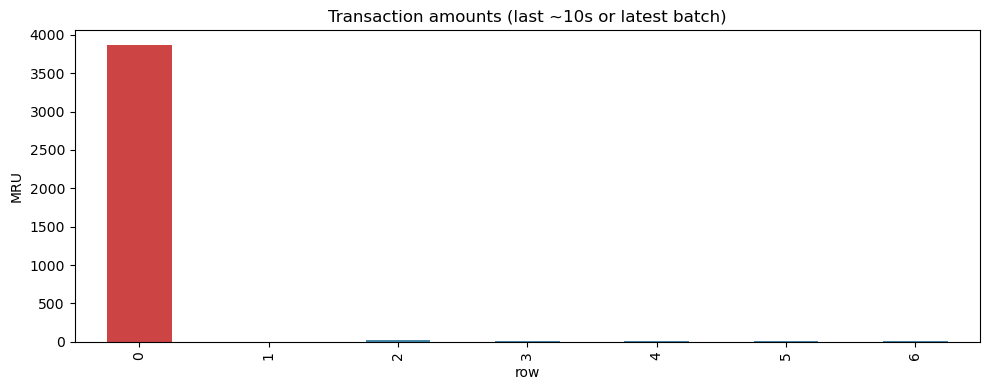

HTML(value='<h3>Last 3 hours (sliding)</h3>')

,user_id,direction,avg_amount,tx_count,total_amount,distinct_counterparties,window_start,window_end,processed_at
328,client_000039,sent,19.15,1,19.15,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:47:39.872762
224,client_000435,received,12.35,2,24.70,2,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:47:39.872762
890,user_a_000004,received,14.12,1,14.12,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:47:39.872762
962,user_a_000196,received,14.71,1,14.71,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:47:39.872762
1002,client_000240,sent,14.79,1,14.79,1,2026-05-21 01:00:00,2026-05-21 04:00:00,2026-05-21 01:47:39.872762
1328,client_000240,sent,14.79,1,14.79,1,2026-05-21 01:30:00,2026-05-21 04:30:00,2026-05-21 01:47:39.872762
1295,user_a_000196,received,14.71,1,14.71,1,2026-05-21 01:30:00,2026-05-21 04:30:00,2026-05-21 01:47:39.872762
313,client_000241,received,9.21,1,9.21,1,2026-05-21 01:30:00,2026-05-21 04:30:00,2026-05-21 01:47:39.872762
1375,client_000320,received,2.11,1,2.11,1,2026-05-21 01:30:00,2026-05-21 04:30:00,2026-05-21 01:47:39.872762
223,client_000435,received,12.35,2,24.70,2,2026-05-21 01:30:00,2026-05-21 04:30:00,2026-05-21 01:47:39.872762


HTML(value='<h3>Last 7 days (sliding)</h3>')

,user_id,direction,avg_amount,tx_count,total_amount,distinct_counterparties,window_start,window_end,processed_at
6323,user_a_000357,received,3864.46,1,3864.46,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:47:44.875158
5669,user_b_000407,sent,2.11,1,2.11,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:47:44.875158
30852,client_000435,received,12.35,2,24.70,2,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:47:44.875158
29415,user_a_000382,received,14.79,1,14.79,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:47:44.875158
9676,client_000320,received,2.11,1,2.11,1,2026-05-21 00:00:00,2026-05-28 00:00:00,2026-05-21 01:47:44.875158
17651,user_a_000276,sent,14.12,1,14.12,1,2026-05-21 01:00:00,2026-05-28 01:00:00,2026-05-21 01:47:44.875158
32620,user_a_000196,sent,10.39,1,10.39,1,2026-05-21 01:00:00,2026-05-28 01:00:00,2026-05-21 01:47:44.875158
32601,client_000039,sent,19.15,1,19.15,1,2026-05-21 01:00:00,2026-05-28 01:00:00,2026-05-21 01:47:44.875158
7616,client_000240,sent,14.79,1,14.79,1,2026-05-21 01:00:00,2026-05-28 01:00:00,2026-05-21 01:47:44.875158
17690,client_000485,sent,3864.46,1,3864.46,1,2026-05-21 01:00:00,2026-05-28 01:00:00,2026-05-21 01:47:44.875158


HTML(value='<h3>Last 3 weeks (sliding)</h3>')

,user_id,direction,avg_amount,tx_count,total_amount,distinct_counterparties,window_start,window_end,processed_at
4888,user_a_000357,received,3864.46,1,3864.46,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:47:51.939143
1956,user_a_000004,received,14.12,1,14.12,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:47:51.939143
17708,client_000485,sent,3864.46,1,3864.46,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:47:51.939143
4612,user_a_000196,received,14.71,1,14.71,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:47:51.939143
13042,user_a_000382,received,14.79,1,14.79,1,2026-05-20 18:00:00,2026-06-10 18:00:00,2026-05-21 01:47:51.939143
17687,user_a_000276,sent,14.12,1,14.12,1,2026-05-21 00:00:00,2026-06-11 00:00:00,2026-05-21 01:47:51.939143
14854,user_a_000004,received,14.12,1,14.12,1,2026-05-21 00:00:00,2026-06-11 00:00:00,2026-05-21 01:47:51.939143
18664,client_000240,sent,14.79,1,14.79,1,2026-05-21 00:00:00,2026-06-11 00:00:00,2026-05-21 01:47:51.939143
18685,user_a_000196,sent,10.39,1,10.39,1,2026-05-21 00:00:00,2026-06-11 00:00:00,2026-05-21 01:47:51.939143
3170,user_a_000270,received,10.39,1,10.39,1,2026-05-21 00:00:00,2026-06-11 00:00:00,2026-05-21 01:47:51.939143


In [ ]:
import time

print("Auto-refresh started (Kernel -> Interrupt to stop)")
try:
    while auto_toggle.value:
        time.sleep(interval_slider.value)
        try:
            render_dashboard()
        except Exception as exc:
            clear_output(wait=True)
            display(widgets.HTML(f"<p style='color:red'>Refresh error: {exc}</p>"))
except KeyboardInterrupt:
    print("Auto-refresh stopped.")